In [2]:
!uv add matplotlib

import kagglehub
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

Resolved 123 packages in 0.66ms
Checked 117 packages in 2ms


In [3]:
# Download latest version
PART_01_DIR = kagglehub.dataset_download("mrgeislinger/popsign-asl-v1-0-game-train-a-e-signs")
# PART_02_DIR = kagglehub.dataset_download("mrgeislinger/popsign-asl-v1-0-game-train-f-j-signs")
# PART_03_DIR = kagglehub.dataset_download("mrgeislinger/popsign-asl-v1-0-game-train-k-o-signs")
# PART_04_DIR = kagglehub.dataset_download("mrgeislinger/popsign-asl-v1-0-game-train-p-t-signs")
# PART_TEST_DIR = kagglehub.dataset_download("mrgeislinger/popsign-asl-v1-0-game-test-signs")
ISLR_DATASET = kagglehub.competition_download('asl-signs')

print("Path to competition files:", ISLR_DATASET)

100%|██████████| 37.4G/37.4G [36:22<00:00, 18.4MB/s]  

Extracting files...


Path to competition files: C:\Users\user2\.cache\kagglehub\competitions\asl-signs


In [3]:
def create_df_from_path(path):
    # Find all mp4 files recursively in the given directory
    video_files = list(Path(path).rglob("*.mp4"))

    # Extract the file path and the label (parent directory name)
    data = {
        "file_path": [str(f) for f in video_files],
        "label": [f.parent.name for f in video_files],
        # add a identifier column to uniquely identify each row
        "id": [f.stem for f in video_files]
    }

    return pd.DataFrame(data)

In [4]:
train_df = pd.concat(
    [
        create_df_from_path(PART_01_DIR),
        # create_df_from_path(PART_02_DIR),
        # create_df_from_path(PART_03_DIR),
        # create_df_from_path(PART_04_DIR)
    ],
    ignore_index=True,
)

# 2. Gather the test set
# test_df = create_df_from_path(PART_TEST_DIR)

# Quick verification
print(f"Total Training Samples: {len(train_df)}")
# print(f"Total Testing Samples: {len(test_df)}")

Total Training Samples: 30867


In [5]:
# Save the train and test dataframes to CSV files
dataframes_dir = Path("./data/dataframes")
dataframes_dir.mkdir(parents=True, exist_ok=True)


train_df.to_csv(dataframes_dir / "train.csv", index=False)
# test_df.to_csv(dataframes_dir / "test.csv", index=False)

In [6]:
label_distribution = train_df.groupby("label").size().reset_index(name="count")


mode_count = label_distribution["count"].mode()
std_count = label_distribution["count"].std()
variance_count = label_distribution["count"].var()


print(f"Mode: {mode_count[0]}")
print(f"Standard Deviation: {std_count}")
print(f"Variance: {variance_count}")

Mode: 459
Standard Deviation: 122.74770156478132
Variance: 15066.99823943662


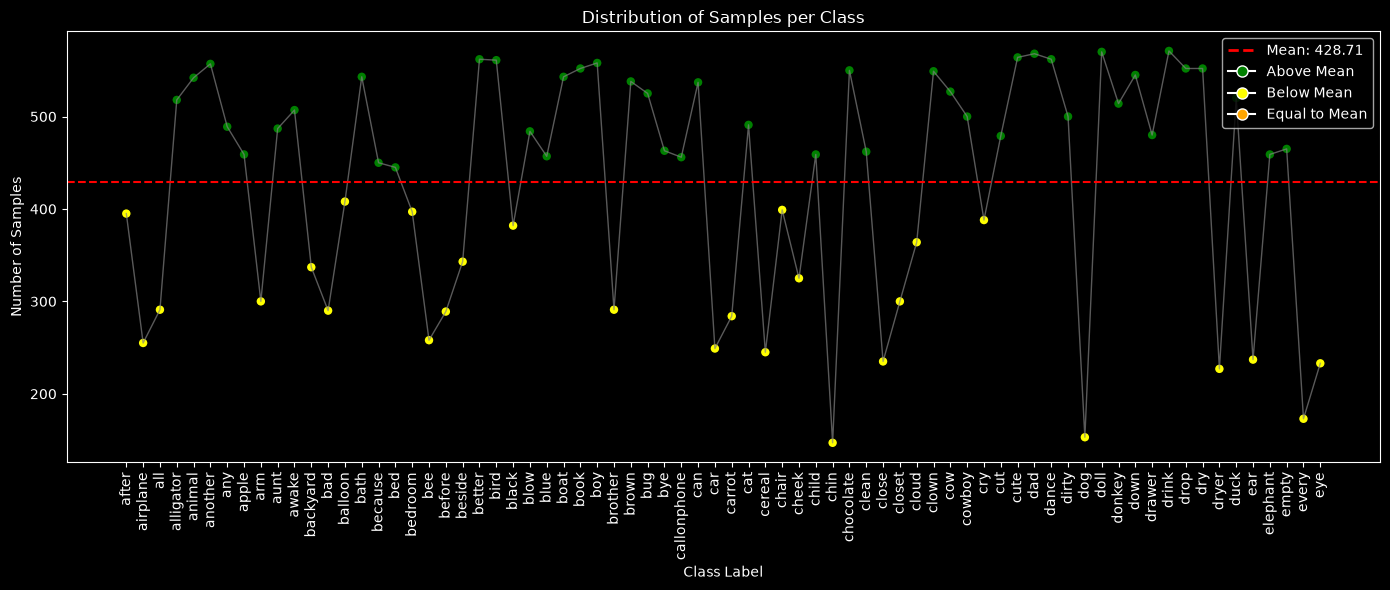

In [7]:
# Training data distribution plot (Line plot) [show the mean]
# color the mean line in red, labels that are above the mean in green, and labels that are below the mean in yellow

from matplotlib.lines import Line2D


plt.figure(figsize=(14, 6))
counts = label_distribution["count"].values
labels = label_distribution["label"].values
x = range(len(labels))
mean_count = counts.mean()

# Line connecting points
plt.plot(x, counts, color="gray", linestyle="-", linewidth=1, alpha=0.7)

# Scatter colored by above/below/equal to mean
colors = [
    "green" if c > mean_count else ("yellow" if c < mean_count else "orange")
    for c in counts
]
plt.scatter(x, counts, c=colors, s=50, edgecolors='k', label="Sample Count")

# Mean line
plt.axhline(y=mean_count, color="r", linestyle="--", label=f"Mean: {mean_count:.2f}")

plt.title("Distribution of Samples per Class")
plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.xticks(x, labels, rotation=90)

# Custom legend
legend_elements = [
    Line2D([0], [0], color='r', lw=2, linestyle='--', label=f'Mean: {mean_count:.2f}'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Above Mean'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='yellow', markersize=8, label='Below Mean'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=8, label='Equal to Mean'),
]
plt.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()
